# 实验二参考答案：机器学习基础与 Speckit 规约驱动建模

> **受众**：Python 进阶课学生（已完成第一讲 Pandas 实验）
> **前置条件**：scikit-learn 已安装；理解 Speckit 三段式结构
> **说明**：本参考答案展示各实验的完整代码实现，供教师评分参考

---
## 实验1：线性回归 + 简单规约（25分）

**数据集**：sklearn `load_diabetes()` — 442名糖尿病患者，用 BMI 预测疾病进展

### speckit_exp1.md 参考内容

```markdown
# 糖尿病线性回归分析

## constitution
- 必须设置 random_state=42 保证结果可复现
- 评估指标必须包含 RMSE（与目标值同量纲）
- X 必须 reshape(-1, 1) 转为二维矩阵

## context
数据来源：sklearn 内置糖尿病数据集（load_diabetes），442 样本 × 10 特征。
提取第 3 列 BMI（体质指数）作为自变量，target（一年后疾病进展量化值）作为因变量，
建立简单线性回归模型。

## 任务列表
- [ ] 任务1：加载糖尿病数据集，提取 BMI 特征和目标值，reshape(-1,1)，打印数据形状
- [ ] 任务2：训练 LinearRegression，输出回归方程和 RMSE，绘制散点图+预测线
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 任务1：加载数据，提取 BMI 特征
diabetes = load_diabetes()
X = diabetes.data[:, 2].reshape(-1, 1)  # BMI 是第3列
y = diabetes.target

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"BMI 范围: [{X.min():.4f}, {X.max():.4f}]")
print(f"目标值范围: [{y.min():.1f}, {y.max():.1f}]")

X shape: (442, 1)
y shape: (442,)
BMI 范围: [-0.0903, 0.1706]
目标值范围: [25.0, 346.0]


回归方程: y = 949.44x + 152.13
RMSE: 62.37


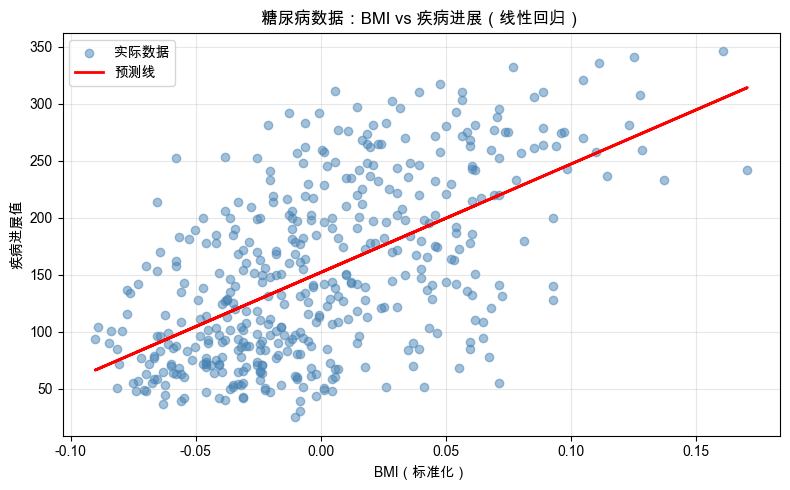

In [ ]:
# 任务2：训练线性回归，输出方程和 RMSE，绘制散点图
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"回归方程: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}")
print(f"RMSE: {rmse:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.5, label='实际数据', color='steelblue')
plt.plot(X, y_pred, color='red', linewidth=2, label='预测线')
plt.xlabel('BMI（标准化）')
plt.ylabel('疾病进展值')
plt.title('糖尿病数据：BMI vs 疾病进展（线性回归）')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 实验2：SVM 分类 + 规约驱动（30分）

**数据集**：sklearn `load_wine()` — 178样本 × 13化学特征 → 3种红酒品种

### speckit_exp2.md 参考内容

```markdown
# 红酒品种 SVM 分类

## constitution
- 必须设置 random_state=42 保证划分可复现
- 必须使用 F1-score（macro）评估多分类效果，不能只看准确率
- 必须用 rbf 核函数（非线性数据）
- 训练集和测试集严格分开，fit 只在训练集上调用

## context
数据来源：sklearn 内置红酒数据集（load_wine），178 个样本，13 项化学成分特征
（酒精度、苹果酸、灰分、镁含量等），目标分类为 3 种品种（cultivar 0/1/2）。

## 任务列表
- [ ] 任务1：加载红酒数据集，80/20 划分训练测试集，打印各集形状
- [ ] 任务2：训练 SVM 分类器（rbf 核，C=100），输出 F1-score
- [ ] 任务3：取酒精度和颜色强度两个特征，绘制 SVM 决策边界
```

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report

# 任务1：加载数据，划分训练测试集
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42
)

print(f"训练集: {X_train.shape}")
print(f"测试集: {X_test.shape}")
print(f"类别分布 - 训练集: {np.bincount(y_train)}")
print(f"类别分布 - 测试集: {np.bincount(y_test)}")

训练集: (142, 13)
测试集: (36, 13)
类别分布 - 训练集: [45 57 40]
类别分布 - 测试集: [14 14  8]


In [ ]:
# 任务2：训练 SVM，输出 F1-score
svm_model = SVC(kernel='rbf', C=100, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

f1 = f1_score(y_test, y_pred_svm, average='macro')
print(f"F1-score (macro): {f1:.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=wine.target_names))

F1-score (macro): 0.8107

              precision    recall  f1-score   support

     class_0       0.93      1.00      0.97        14
     class_1       0.91      0.71      0.80        14
     class_2       0.60      0.75      0.67         8

    accuracy                           0.83        36
   macro avg       0.81      0.82      0.81        36
weighted avg       0.85      0.83      0.83        36



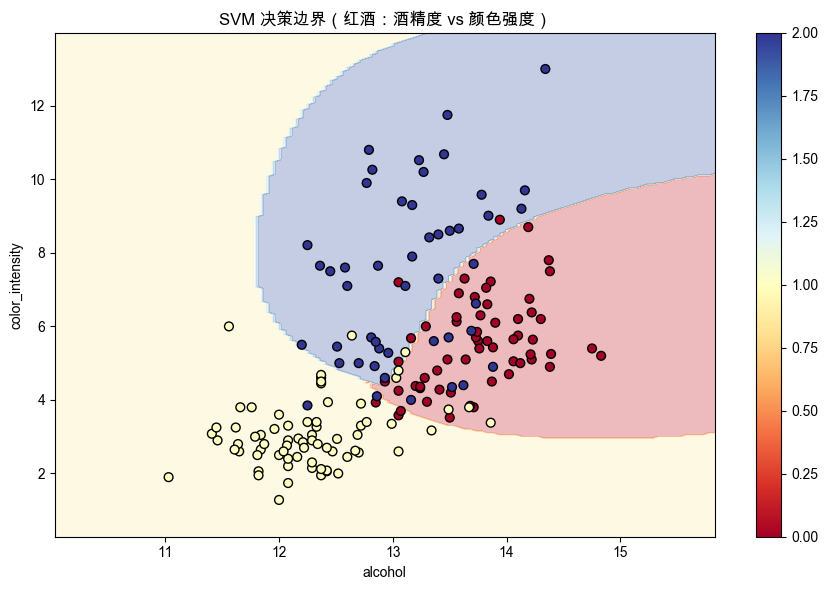

In [ ]:
# 任务3：决策边界可视化（取酒精度 + 颜色强度两个特征）
# 酒精度: feature 0, 颜色强度: feature 9
feat_idx = [0, 9]
X_2d = X_wine[:, feat_idx]

svm_2d = SVC(kernel='rbf', C=100, random_state=42)
svm_2d.fit(X_2d, y_wine)

def make_meshgrid(x, y, h=0.05):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    return ax.contourf(xx, yy, Z, **params)

fig, ax = plt.subplots(figsize=(9, 6))
xx, yy = make_meshgrid(X_2d[:, 0], X_2d[:, 1])
plot_contours(ax, svm_2d, xx, yy, cmap=plt.cm.RdYlBu, alpha=0.3)

scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_wine,
                     cmap=plt.cm.RdYlBu, edgecolors='k', s=40)
ax.set_xlabel(wine.feature_names[feat_idx[0]])
ax.set_ylabel(wine.feature_names[feat_idx[1]])
ax.set_title('SVM 决策边界（红酒：酒精度 vs 颜色强度）')
plt.colorbar(scatter)
plt.tight_layout()
plt.show()

---
## 实验3：乳腺癌数据聚类与降维验证（45分）

**数据集**：sklearn `load_breast_cancer()` — 569样本 × 30特征（细胞核形态学指标）

### speckit_exp3.md 参考内容

```markdown
# 乳腺癌数据无监督聚类与降维验证

## constitution
- PCA 前必须用 StandardScaler 标准化（30个特征量纲差异极大）
- K-means 必须使用 k-means++ 初始化，random_state=42
- K 值选择必须基于肘部法则，不可随意指定
- 不可将真实诊断标签用于聚类训练，仅用于最终验证对比

## context
数据来源：sklearn 内置乳腺癌诊断数据集（load_breast_cancer），569 例肿瘤样本，
30 项细胞核特征（半径、纹理、周长、面积、光滑度等的均值/标准差/最大值）。
真实标签为恶性(0)/良性(1)，但本实验忽略标签进行无监督聚类，
再用 PCA 降维可视化验证聚类质量。

## 任务列表
- [ ] 任务1：加载乳腺癌数据集，打印数据形状和前5个特征名
- [ ] 任务2：肘部法则确定 K（K=2-9），绘制 inertia 曲线
- [ ] 任务3：K-means++ 聚类（选定 K，random_state=42），打印各簇样本数
- [ ] 任务4：StandardScaler + PCA 降至 2 维，按聚类标签上色，打印解释方差比
```

In [ ]:
from sklearn.datasets import load_breast_cancer

# 任务1：加载数据，打印形状和特征名
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target  # 仅用于最终验证，不参与聚类

print(f"数据形状: {X_cancer.shape}")
print(f"样本数: {X_cancer.shape[0]}, 特征数: {X_cancer.shape[1]}")
print(f"前5个特征名: {list(cancer.feature_names[:5])}")
print(f"真实标签分布（仅供验证）: 恶性={sum(y_cancer==0)}, 良性={sum(y_cancer==1)}")

数据形状: (569, 30)
样本数: 569, 特征数: 30
前5个特征名: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]
真实标签分布（仅供验证）: 恶性=212, 良性=357


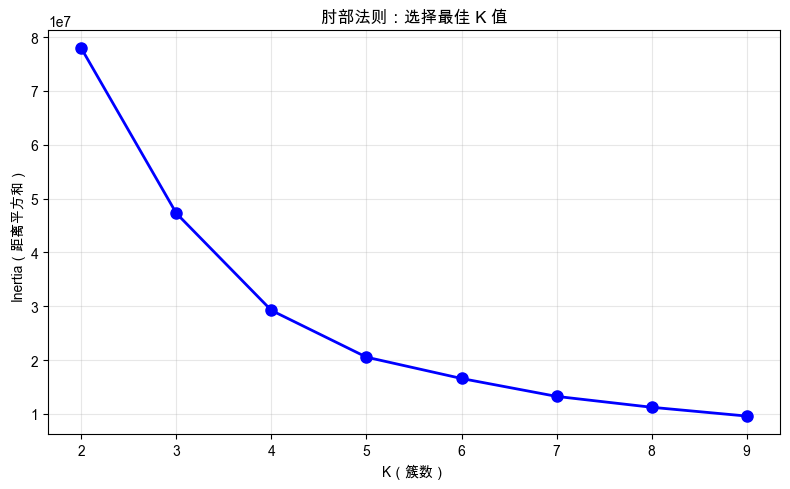

观察：K=2 处有明显拐点（inertia 下降速度突然变缓），选择 K=2


In [ ]:
from sklearn.cluster import KMeans

# 任务2：肘部法则确定 K
inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_cancer)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K（簇数）')
plt.ylabel('Inertia（距离平方和）')
plt.title('肘部法则：选择最佳 K 值')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("观察：K=2 处有明显拐点（inertia 下降速度突然变缓），选择 K=2")

选定 K = 2
簇0 样本数: 131
簇1 样本数: 438

与真实标签对比（验证聚类质量）:
  簇0 中恶性占比: 99.24%
  簇1 中良性占比: 81.28%


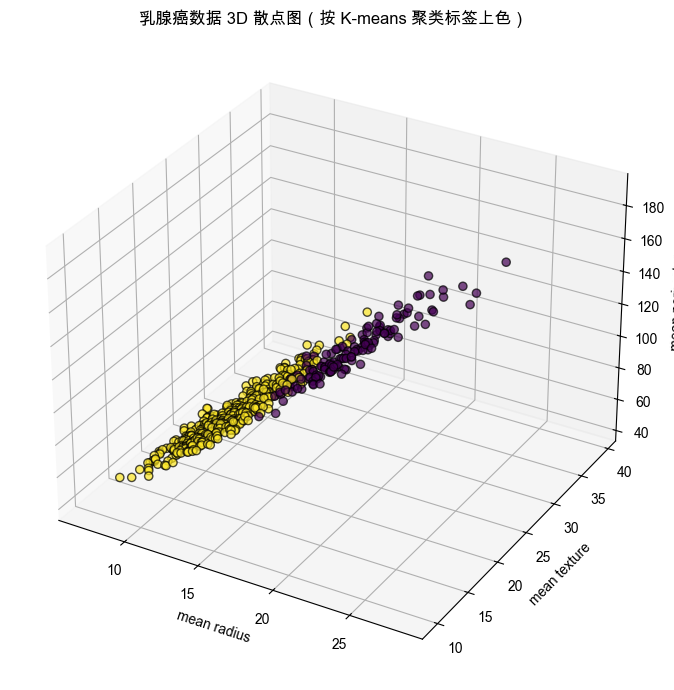

In [ ]:
# 任务3：K-means++ 聚类（K=2）
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cancer)

print(f"选定 K = 2")
print(f"簇0 样本数: {sum(clusters == 0)}")
print(f"簇1 样本数: {sum(clusters == 1)}")
print(f"\n与真实标签对比（验证聚类质量）:")
print(f"  簇0 中恶性占比: {sum((clusters==0) & (y_cancer==0)) / sum(clusters==0):.2%}")
print(f"  簇1 中良性占比: {sum((clusters==1) & (y_cancer==1)) / sum(clusters==1):.2%}")

# 3D 散点图可视化（取前 3 个特征）
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_cancer[:, 0], X_cancer[:, 1], X_cancer[:, 2],
    c=clusters, cmap='viridis', s=35, alpha=0.7, edgecolors='k'
)

ax.set_xlabel(cancer.feature_names[0])
ax.set_ylabel(cancer.feature_names[1])
ax.set_zlabel(cancer.feature_names[2])
ax.set_title('乳腺癌数据 3D 散点图（按 K-means 聚类标签上色）')

plt.tight_layout()
plt.show()

主成分1 解释方差比: 0.4427
主成分2 解释方差比: 0.1897
累计解释方差: 0.6324


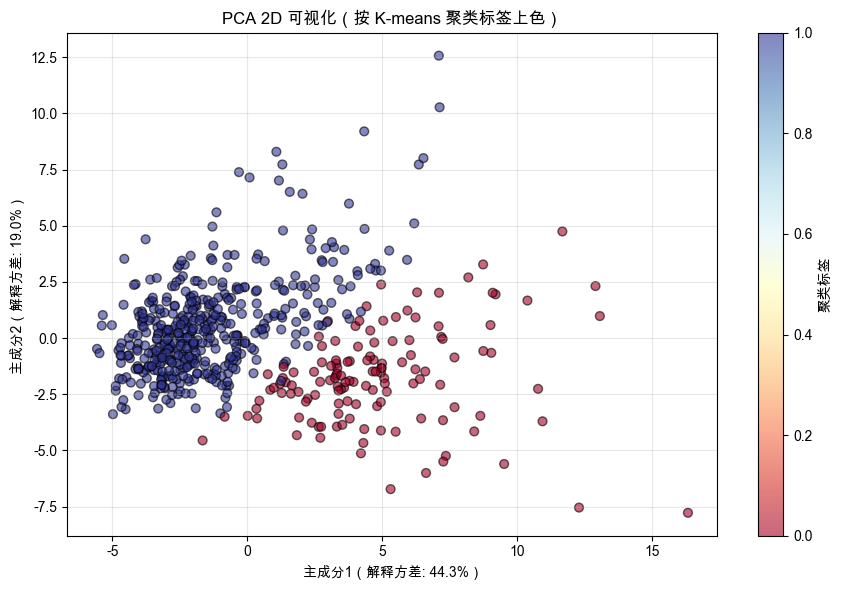

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 任务4：StandardScaler + PCA 降维可视化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cancer)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"主成分1 解释方差比: {pca.explained_variance_ratio_[0]:.4f}")
print(f"主成分2 解释方差比: {pca.explained_variance_ratio_[1]:.4f}")
print(f"累计解释方差: {sum(pca.explained_variance_ratio_):.4f}")

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters,
                      cmap='RdYlBu', alpha=0.6, edgecolors='k', s=40)
plt.xlabel(f'主成分1（解释方差: {pca.explained_variance_ratio_[0]:.1%}）')
plt.ylabel(f'主成分2（解释方差: {pca.explained_variance_ratio_[1]:.1%}）')
plt.title('PCA 2D 可视化（按 K-means 聚类标签上色）')
plt.colorbar(scatter, label='聚类标签')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 知识点速查表

| 算法 | 关键 API | 核心参数 |
|------|---------|---------|
| 线性回归 | `LinearRegression().fit(X, y)` | X 必须二维（reshape） |
| SVM | `SVC(kernel='rbf', C=100)` | kernel, C, random_state |
| K-means | `KMeans(n_clusters=k, init='k-means++')` | n_clusters, random_state |
| PCA | `PCA(n_components=2).fit_transform(X)` | n_components |
| 标准化 | `StandardScaler().fit_transform(X)` | PCA 前必备 |

## Speckit 关键概念速查表

| 概念 | 说明 |
|------|------|
| constitution | 不可违反的硬约束（random_state、评估指标、防数据泄露）|
| context | 数据来源、字段含义、分析目标 |
| 任务列表 | 可执行、可验证的步骤（`- [ ]` 格式）|
| @speckit.md | 引用规约文件，AI 全程遵守 constitution |
| Speckit vs 两段式 | 单任务用两段式 Prompt，多步骤项目用 Speckit |